# Data Formatting

In [38]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [39]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['GEOID']).copy()
HD_ct['GEOID'] = HD_ct['GEOID'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct[["GEOID", "disasterNumber", "Tre_p"]], HD_zip[["GEOID", "disasterNumber", "Tre_p"]]],ignore_index=True)
acs_all = pd.concat([acs_ct, acs_zip])

In [40]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [41]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)

cum_df_12 = df_combined[[24,'GEOID','disasterNumber']].copy()
cum_df_12 = cum_df_12.rename(columns={24: 'cum_att'})
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

cum_df_1 = df_combined[[13,'GEOID','disasterNumber']].copy()
cum_df_1 = cum_df_1.rename(columns={13: 'cum_att'})
cum_df_1["GEOID"] = cum_df_1["GEOID"].astype(str)

cum_df_0 = df_combined[[12,'GEOID','disasterNumber']].copy()
cum_df_0 = cum_df_0.rename(columns={12: 'cum_att'})
cum_df_0["GEOID"] = cum_df_0["GEOID"].astype(str)

cum_df_neg1 = df_combined[[11,'GEOID','disasterNumber']].copy()
cum_df_neg1 = cum_df_neg1.rename(columns={11: 'cum_att'})
cum_df_neg1["GEOID"] = cum_df_neg1["GEOID"].astype(str)

In [42]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

cum_df_12["disasterNumber"] = cum_df_12["disasterNumber"].astype(str)
cum_df_1["disasterNumber"] = cum_df_1["disasterNumber"].astype(str)
cum_df_0["disasterNumber"] = cum_df_0["disasterNumber"].astype(str)
cum_df_neg1["disasterNumber"] = cum_df_neg1["disasterNumber"].astype(str)
HD_all["disasterNumber"] = HD_all["disasterNumber"].astype(str)

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on=["disasterNumber", "GEOID"], how="left")\
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")\
                     .rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})
merged_df_1 = cum_df_1.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on=["disasterNumber", "GEOID"], how="left")\
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")\
                     .rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})
merged_df_0 = cum_df_0.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on=["disasterNumber", "GEOID"], how="left")\
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")\
                     .rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})
merged_df_neg1 = cum_df_neg1.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on=["disasterNumber", "GEOID"], how="left")\
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")\
                     .rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})

In [43]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
df_disdecall = pd.read_csv("/mnt/drive/MyDrive/Colab_data/DisasterDeclarationsSummaries.csv")

dec = pd.merge(dec, df_disdecall, left_on='disasterNumber', right_on='disasterNumber', how='left').copy()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ATT Regression

## Normal regression

In [85]:
merged_df = merged_df_neg1.copy()

In [86]:
# --- Remove Inf and drop missing ---
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan)

y_clean = merged_df_clean["cum_att"].astype(float)

# Independent variables
merged_df_clean['D_TH'] = merged_df_clean['Tre_p']
merged_df_clean['Black_Population_Ratio'] = merged_df_clean['Black_Population'] / merged_df_clean['Total_Population']
merged_df_clean['zip'] = merged_df_clean['GEOID'].apply(lambda x: 1 if len(str(x)) == 5 else 0)


In [87]:

# =====================================================
# Load RMSPE
# =====================================================

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

att_df = pd.read_csv(save_dir + "att_all.csv")

# disaster_id × GEOID ごとに1行だけ残す
rmspe_df = (
    att_df[
        ["disaster_id", "GEOID", "RMSPE"]
    ]
    .drop_duplicates()
)

# 型を合わせる
rmspe_df["disaster_id"] = rmspe_df["disaster_id"].astype(str)
rmspe_df["GEOID"] = rmspe_df["GEOID"].astype(str)

merged_df_clean["disasterNumber"] = (
    merged_df_clean["disasterNumber"]
    .astype(float)
    .astype(int)
    .astype(str)
)

merged_df_clean["GEOID"] = merged_df_clean["GEOID"].astype(str)

# =====================================================
# Merge
# =====================================================

merged_df_clean = merged_df_clean.merge(
    rmspe_df,
    left_on=["disasterNumber", "GEOID"],
    right_on=["disaster_id", "GEOID"],
    how="left"
)

merged_df_clean = merged_df_clean.drop(columns="disaster_id")

print("Matched RMSPE:", merged_df_clean["RMSPE"].notna().sum())
print("Missing RMSPE:", merged_df_clean["RMSPE"].isna().sum())

Matched RMSPE: 2642
Missing RMSPE: 61


In [88]:
merged_df_clean = merged_df_clean[merged_df_clean["city"] != "Richmond, VA"]

In [89]:
x_vars = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_bias_high_zip",
    "nbhd_bias_zip",
    "bias_grp_mem_high_zip",
    "bias_grp_mem_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_high_zip",
    "exposure_grp_mem_zip",
    "ec_grp_mem_high_zip",
    "nbhd_ec_high_zip",
    "ec_high_zip",
    "ec_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_zip"
]

x_vars_plot = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_grp_mem_zip",
    "ec_zip"
]


control_vars = [
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
    "disasterNumber",
    "D_TH"
]

y_var = "cum_att"

In [90]:
print(len(merged_df_clean))

cols = [y_var] + x_vars + control_vars + ["RMSPE"]
merged_df_clean["D_TH"] = merged_df_clean["D_TH"].fillna(0)

print(merged_df_clean[cols].isna().sum().sort_values(ascending=False))

2697
nbhd_bias_zip                637
nbhd_bias_high_zip           637
nbhd_ec_high_zip             637
nbhd_ec_zip                  637
nbhd_exposure_zip            637
bias_grp_mem_high_zip        585
exposure_grp_mem_zip         585
ec_grp_mem_high_zip          585
ec_grp_mem_zip               585
exposure_grp_mem_high_zip    585
bias_grp_mem_zip             585
ec_high_zip                  583
ec_zip                       583
civic_organizations_zip      582
volunteering_rate_zip        582
RMSPE                         55
Median_Household_Income       12
Black_Population_Ratio         1
cum_att                        0
Renter_Households              0
disasterNumber                 0
D_TH                           0
dtype: int64


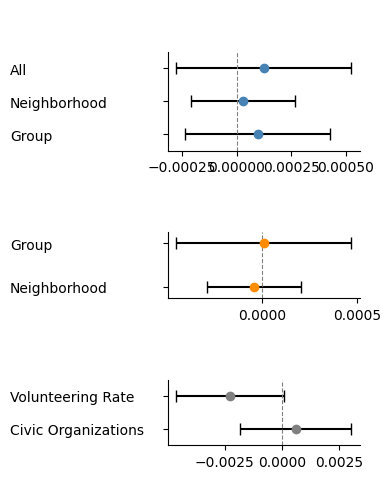

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
x_label_mapping = {
    "civic_organizations_zip": "Civic Organizations",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Friending Bias (high SE)",
    "nbhd_bias_zip": "Neighborhood\n Friending Bias",
    "bias_grp_mem_high_zip": "Group Friending Bias (high SE)",
    "bias_grp_mem_zip": "Group Friending Bias",
    "nbhd_exposure_zip": "Neighborhood",
    "exposure_grp_mem_high_zip": "Group Exposure (high SE)",
    "exposure_grp_mem_zip": "Group",
    "ec_grp_mem_high_zip": "Group Econ Connectedness (high SE)",
    "nbhd_ec_high_zip": "Neighborhood Econ Connectedness (high SE)",
    "ec_high_zip": "Economic Connectedness (high SE)",
    "nbhd_ec_zip": "Neighborhood",
    "ec_grp_mem_zip": "Group",
    "ec_zip": "All",
}

# --- Category ---
def get_category(var_name):
    if "ec" in var_name:
        return "economic connectedness"
    elif "exposure" in var_name:
        return "exposure"
    elif "bias" in var_name:
        return "friending bias"
    else:
        return "civic engagement"

color_mapping = {
    "economic connectedness": "steelblue",
    "exposure": "darkorange",
    "friending bias": "seagreen",
    "civic engagement": "grey"
}

# ==============================
# Regression
# ==============================
def run_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    cluster_var="disasterNumber"
):
    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:
        # =========================
        # Subset
        # =========================
        cols = [y_var, x] + controls
        df_sub = df[cols].copy()

        # =========================
        # numeric coercion
        # =========================
        df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
        df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # =========================
        # y / X
        # =========================
        y = df_sub[y_var].astype(float)
        X = df_sub.drop(columns=[y_var])

        # =========================
        # Explicit FE handling
        # =========================
        if "disasterNumber" in X.columns:
            X["disasterNumber"] = X["disasterNumber"].astype("category")

        if "zip" in X.columns:
            X["zip"] = X["zip"].astype("category")

        # =========================
        # Dummy
        # =========================
        X = pd.get_dummies(X, drop_first=True)

        X = X.astype(float)

        X = sm.add_constant(X, has_constant="add")

        # =========================
        # Cluster
        # =========================
        groups = df_sub[cluster_var]

        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        results.append({
            "x_variable": x,
            "Coefficient": model.params[x],
            "CI_Lower": model.conf_int().loc[x, 0],
            "CI_Upper": model.conf_int().loc[x, 1],
            "p_value": model.pvalues[x]
        })

    return pd.DataFrame(results),regression_results, latex_results


# --- Plot ---
def plot_coefficients_by_category(df):
    df["category"] = df["x_variable"].apply(get_category)
    categories = list(df["category"].unique())[::-1]

    height_ratios = [len(df[df["category"] == cat]) for cat in categories]

    global_min = df["CI_Lower"].min()-0.05
    global_max = df["CI_Upper"].max()+0.05

    fig = plt.figure(figsize=(3.8, sum(height_ratios)*0.7))
    gs = gridspec.GridSpec(len(categories), 1, height_ratios=height_ratios)

    for idx, cat in enumerate(categories):
        ax = fig.add_subplot(gs[idx])
        sub_df = df[df["category"] == cat]

        for i, row in sub_df.iterrows():
            color = color_mapping.get(cat, "black")
            ci_lower = row["Coefficient"] - row["CI_Lower"]
            ci_upper = row["CI_Upper"] - row["Coefficient"]

            # significance star
            if row["p_value"] < 0.001:
                signif = "***"
            elif row["p_value"] < 0.01:
                signif = "**"
            elif row["p_value"] < 0.05:
                signif = "*"
            else:
                signif = ""

            ax.errorbar(
                row["Coefficient"], i,
                xerr=[[ci_lower], [ci_upper]],
                fmt="o", color=color, ecolor="black",
                capsize=4, markersize=6
            )

            if signif:
                ax.text(row["Coefficient"], i, " " + signif,
                        va="center", fontsize=15)

        ax.set_title(cat.capitalize(), fontsize=1, color="white", loc = "left", pad = 30)
        ax.set_yticks(sub_df.index)
        ax.set_yticklabels([x_label_mapping.get(v, v) for v in sub_df["x_variable"]],fontsize=10,ha="left")
        ax.tick_params(axis='y', pad=110)


        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)

        ymin = sub_df.index.min() - 0.5
        ymax = sub_df.index.max() + 0.5
        ax.set_ylim(ymin, ymax)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


    plt.tight_layout()
    plt.savefig("figure.png", dpi=200, bbox_inches="tight")
    plt.show()

df_controls, regression_results, latex_results = run_regression(
    merged_df_clean,
    x_vars,
    controls=control_vars
)
coef_df_plot = df_controls[df_controls["x_variable"].isin(x_vars_plot)].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [92]:
for var, model in regression_results.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     66.48
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           2.51e-08
Time:                        02:15:48   Log-Likelihood:                 11860.
No. Observations:                2110   AIC:                        -2.368e+04
Df Residuals:                    2092   BIC:                        -2.358e+04
Df Model:                          17                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     132.6
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           4.53e-10
Time:                        02:15:49   Log-Likelihood:                 11534.
No. Observations:                2055   AIC:                        -2.303e+04
Df Residuals:                    2037   BIC:                        -2.293e+04
Df Model:                          17                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     83.17
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           6.88e-09
Time:                        02:15:49   Log-Likelihood:                 11534.
No. Observations:                2055   AIC:                        -2.303e+04
Df Residuals:                    2037   BIC:                        -2.293e+04
Df Model:                          17                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [93]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 2685.000 & -0.001 & 0.001 & -0.004 & -0.001 & -0.000 & -0.000 & 0.002 \\
D_TH & 2685.000 & 0.002 & 0.010 & 0.000 & 0.000 & 0.000 & 0.000 & 0.112 \\
Renter_Households & 2685.000 & 971.788 & 2185.022 & 0.000 & 377.000 & 630.000 & 1004.000 & 29069.000 \\
Black_Population_Ratio & 2685.000 & 0.286 & 0.293 & 0.000 & 0.053 & 0.168 & 0.424 & 1.000 \\
Median_Household_Income & 2685.000 & 69011.150 & 35487.081 & 2499.000 & 44671.000 & 61250.000 & 85183.000 & 250001.000 \\
ec_zip & 2109.000 & 0.773 & 0.233 & 0.357 & 0.596 & 0.755 & 0.925 & 1.500 \\
nbhd_ec_zip & 2055.000 & 0.696 & 0.391 & 0.095 & 0.395 & 0.637 & 0.934 & 1.869 \\
ec_grp_mem_zip & 2107.000 & 0.845 & 0.278 & 0.282 & 0.642 & 0.833 & 1.018 & 1.632 \\
ec_high_zip & 2109.000 & 1.338 & 0.238 & 0.713 & 1.209 & 1.355 & 1.507 & 1.826 \\
nbhd_ec_high_zip & 2055.000 & 1.183 & 0.415 & 0.233 & 0.917 & 1.216 & 1.500 & 1.937 \\
ec_grp_mem

## Regression with placebo variance

   disaster_id  placebo_GEOID     RMSPE  cumATT12
0         4735    47037016800  0.000108 -0.001897
1         4735    47037015806  0.003291  0.015358
2         4735    47037010601  0.002388  0.008602
3         4735    47037017200  0.001237  0.018158
4         4735    47037015618  0.001784 -0.021070

Summary of placebo variance


,placebo_var,placebo_sd,n_placebo
count,1678.000000,1678.000000,2697.000000
mean,0.001130,0.029695,25.563589
std,0.001395,0.015754,24.908835
min,0.000000,0.000000,0.000000
25%,0.000520,0.022806,4.000000
50%,0.000756,0.027489,23.000000
75%,0.001389,0.037274,40.000000
max,0.018458,0.135862,100.000000



Observations with enough placebo: 1678
Total observations: 2697


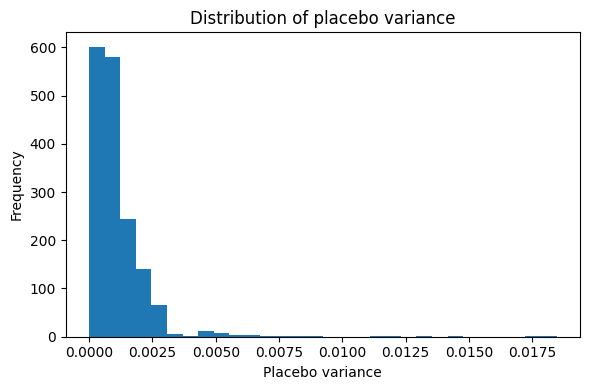

In [16]:
import numpy as np
import pandas as pd

# =====================================================
# Load placebo library
# =====================================================

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
placebo_library = pd.read_csv(
    save_dir + "placebo_library.csv"
)

print(placebo_library.head())

# =====================================================
# Parameters
# =====================================================

LOWER = 0.5
UPPER = 2.0
MIN_PLACEBO = 10
EPS = 1e-6

# =====================================================
# Compute placebo variance for each treated tract
# =====================================================

placebo_var_list = []

for _, row in merged_df_clean.iterrows():

    disaster = str(row["disasterNumber"])
    rmspe = row["RMSPE"]

    # -----------------------------
    # Same disaster
    # -----------------------------
    subset = placebo_library[
        placebo_library["disaster_id"].astype(str) == disaster
    ].copy()

    # -----------------------------
    # RMSPE filter
    # -----------------------------
    subset = subset[
        (subset["RMSPE"] >= LOWER * rmspe) &
        (subset["RMSPE"] <= UPPER * rmspe)
    ]

    n_placebo = len(subset)

    if n_placebo < MIN_PLACEBO:

        placebo_var = np.nan
        placebo_sd = np.nan

    else:

        placebo_var = subset["cumATT12"].var(ddof=1)

        placebo_sd = np.sqrt(placebo_var)

    placebo_var_list.append({

        "placebo_var": placebo_var,

        "placebo_sd": placebo_sd,

        "n_placebo": n_placebo

    })

# =====================================================
# Merge
# =====================================================

placebo_var_df = pd.DataFrame(placebo_var_list)

merged_df_clean = merged_df_clean.drop(
    columns=["placebo_var", "placebo_sd", "n_placebo"],
    errors="ignore"
)

merged_df_clean = pd.concat(
    [
        merged_df_clean.reset_index(drop=True),
        placebo_var_df
    ],
    axis=1
)

# =====================================================
# Summary
# =====================================================

print("\nSummary of placebo variance")

display(

    merged_df_clean[
        [
            "placebo_var",
            "placebo_sd",
            "n_placebo"
        ]
    ].describe()

)

print(
    "\nObservations with enough placebo:",
    (merged_df_clean["n_placebo"] >= MIN_PLACEBO).sum()
)

print(
    "Total observations:",
    len(merged_df_clean)
)

# =====================================================
# Histogram
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(
    merged_df_clean["placebo_var"].dropna(),
    bins=30
)

plt.xlabel("Placebo variance")

plt.ylabel("Frequency")

plt.title("Distribution of placebo variance")

plt.tight_layout()

plt.show()

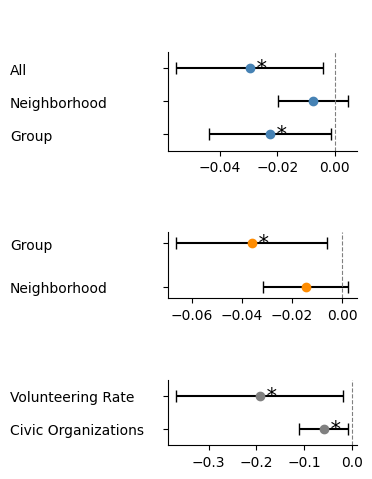

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==============================
# IVW Regression
# ==============================

def run_ivw_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    weight_var="placebo_var",
    eps=1e-6
):

    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:

        cols = [y_var, x] + controls + [weight_var]

        df_sub = df[cols].copy()

        # ------------------------------------
        # remove missing placebo variance
        # ------------------------------------

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        df_sub = df_sub[
            df_sub[weight_var] > 0
        ].copy()

        # ------------------------------------
        # inverse variance weight
        # ------------------------------------

        df_sub["weight"] = 1 / (
            df_sub[weight_var] + eps
        )

        # ------------------------------------

        y = pd.to_numeric(
            df_sub[y_var]
        )

        X = df_sub.drop(
            columns=[
                y_var,
                weight_var,
                "weight"
            ]
        )

        if "disasterNumber" in X.columns:
            X["disasterNumber"] = (
                X["disasterNumber"]
                .astype("category")
            )

        if "zip" in X.columns:
            X["zip"] = (
                X["zip"]
                .astype("category")
            )

        X = pd.get_dummies(
            X,
            drop_first=True
        )

        X = X.astype(float)

        X = sm.add_constant(
            X,
            has_constant="add"
        )

        # ------------------------------------
        # Clustered WLS
        # ------------------------------------

        groups = df_sub["disasterNumber"]

        model = sm.WLS(
            y,
            X,
            weights=df_sub["weight"]
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": groups
            }
        )

        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        ci = model.conf_int()

        results.append({

            "x_variable": x,

            "Coefficient": model.params[x],

            "CI_Lower": ci.loc[x, 0],

            "CI_Upper": ci.loc[x, 1],

            "p_value": model.pvalues[x]

        })

    return (
        pd.DataFrame(results),
        regression_results,
        latex_results
    )


# ===================================
# Run
# ===================================

df_controls_ivw, regression_results_ivw, latex_results_ivw = run_ivw_regression(
    merged_df_clean,
    x_vars,
    control_vars
)

coef_df_plot = df_controls_ivw[
    df_controls_ivw["x_variable"].isin(
        x_vars_plot
    )
].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [18]:
for var, model in regression_results_ivw.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            WLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.098
Model:                            WLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     1559.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           4.04e-14
Time:                        23:49:10   Log-Likelihood:                 2202.3
No. Observations:                1195   AIC:                            -4373.
Df Residuals:                    1179   BIC:                            -4291.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

In [19]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 2685.000 & -0.013 & 0.041 & -0.188 & -0.033 & -0.013 & 0.004 & 0.431 \\
D_TH & 2685.000 & 0.002 & 0.010 & 0.000 & 0.000 & 0.000 & 0.000 & 0.112 \\
Renter_Households & 2685.000 & 971.788 & 2185.022 & 0.000 & 377.000 & 630.000 & 1004.000 & 29069.000 \\
Black_Population_Ratio & 2685.000 & 0.286 & 0.293 & 0.000 & 0.053 & 0.168 & 0.424 & 1.000 \\
Median_Household_Income & 2685.000 & 69011.150 & 35487.081 & 2499.000 & 44671.000 & 61250.000 & 85183.000 & 250001.000 \\
ec_zip & 2109.000 & 0.773 & 0.233 & 0.357 & 0.596 & 0.755 & 0.925 & 1.500 \\
nbhd_ec_zip & 2055.000 & 0.696 & 0.391 & 0.095 & 0.395 & 0.637 & 0.934 & 1.869 \\
ec_grp_mem_zip & 2107.000 & 0.845 & 0.278 & 0.282 & 0.642 & 0.833 & 1.018 & 1.632 \\
ec_high_zip & 2109.000 & 1.338 & 0.238 & 0.713 & 1.209 & 1.355 & 1.507 & 1.826 \\
nbhd_ec_high_zip & 2055.000 & 1.183 & 0.415 & 0.233 & 0.917 & 1.216 & 1.500 & 1.937 \\
ec_grp_mem_

##Spatial regression

In [20]:
# ============================================================
# Moran's I of OLS residuals (all regressions)
# ============================================================

!pip -q install libpysal esda geopandas

import geopandas as gpd
import pandas as pd
import numpy as np
import statsmodels.api as sm

from glob import glob
import os
import zipfile

from libpysal.weights import Queen
from esda.moran import Moran

# -------------------------------------------------------
# Read tract shapefiles
# -------------------------------------------------------

base_dir = "/mnt/drive/MyDrive/Colab_data"

zip_files = glob(os.path.join(base_dir, "*.zip"))

for z in zip_files:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall(base_dir)

shapefiles = (
    glob(os.path.join(base_dir, "tl_2021_*_tract.shp"))
    + glob(os.path.join(base_dir, "tl_2022_*_tract.shp"))
)

gdfs = [gpd.read_file(shp) for shp in shapefiles]

tracts = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

tracts["GEOID"] = tracts["GEOID"].astype(str)

# -------------------------------------------------------
# Moran's I for each regression
# -------------------------------------------------------

results = []

for x in x_vars:

    print(f"Running {x}...")

    cols = [y_var, x] + control_vars + ["GEOID"]

    df_sub = merged_df_clean[cols].copy()

    df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
    df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

    df_sub = (
        df_sub
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    # tract only
    df_sub = df_sub[df_sub["GEOID"].str.len() == 11].copy()

    y = df_sub[y_var].astype(float)

    X = df_sub.drop(columns=[y_var, "GEOID"])

    if "disasterNumber" in X.columns:
        X["disasterNumber"] = X["disasterNumber"].astype("category")

    if "zip" in X.columns:
        X["zip"] = X["zip"].astype("category")

    X = pd.get_dummies(X, drop_first=True)
    X = X.astype(float)
    X = sm.add_constant(X)

    groups = df_sub["disasterNumber"]

    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    df_sub["residual"] = model.resid.values

    # merge shapefile
    gdf = tracts.merge(
        df_sub[["GEOID", "residual"]],
        on="GEOID",
        how="inner"
    )

    # Queen weights
    w = Queen.from_dataframe(gdf)

    # remove islands
    if len(w.islands) > 0:
        gdf = gdf.drop(index=w.islands).reset_index(drop=True)
        w = Queen.from_dataframe(gdf)

    w.transform = "R"

    moran = Moran(
        gdf["residual"].values,
        w,
        permutations=9999
    )

    results.append({
        "Variable": x,
        "N": len(gdf),
        "Moran_I": moran.I,
        "Expected_I": moran.EI,
        "Z": moran.z_sim,
        "P_value": moran.p_sim
    })

# -------------------------------------------------------
# Results
# -------------------------------------------------------

moran_results = (
    pd.DataFrame(results)
    .sort_values("P_value")
    .reset_index(drop=True)
)

print("\n================ Moran's I of OLS Residuals ================\n")
display(moran_results)

Running civic_organizations_zip...


/tmp/ipykernel_826/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_826/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running volunteering_rate_zip...


/tmp/ipykernel_826/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_826/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running nbhd_bias_high_zip...


...

/tmp/ipykernel_826/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 27 disconnected components.
 There are 6 islands with ids: 59, 151, 1914, 1916, 1926, 1978.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_826/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Running ec_zip...


/tmp/ipykernel_826/972147342.py:102: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_826/972147342.py:107: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)



================ Moran's I of OLS Residuals ================



,Variable,N,Moran_I,Expected_I,Z,P_value
0,civic_organizations_zip,2051,0.093807,-0.000488,7.217857,0.0001
1,volunteering_rate_zip,2051,0.088088,-0.000488,6.818274,0.0001
2,nbhd_bias_high_zip,2001,0.092576,-0.000500,7.065287,0.0001
3,nbhd_bias_zip,2001,0.089963,-0.000500,6.936261,0.0001
4,bias_grp_mem_high_zip,2050,0.091273,-0.000488,6.935338,0.0001
5,bias_grp_mem_zip,2050,0.095511,-0.000488,7.365384,0.0001
6,nbhd_exposure_zip,2001,0.087272,-0.000500,6.721352,0.0001
7,exposure_grp_mem_high_zip,2050,0.084540,-0.000488,6.530306,0.0001
8,exposure_grp_mem_zip,2050,0.089109,-0.000488,6.852536,0.0001
9,ec_grp_mem_high_zip,2050,0.086794,-0.000488,6.755600,0.0001


In [21]:
# ==========================================================
# Spatial Lag Model (SLM) and Spatial Error Model (SEM)
# ==========================================================

!pip -q install spreg libpysal geopandas

import pandas as pd
import numpy as np

from libpysal.weights import Queen
from spreg import ML_Lag, ML_Error

tracts["GEOID"] = tracts["GEOID"].astype(str)

# -------------------------------------------------
# Save models
# -------------------------------------------------

slm_models = {}
sem_models = {}

results = []

for x in x_vars:

    print(f"Running {x}")

    cols = [y_var, x] + control_vars + ["GEOID"]

    df_sub = merged_df_clean[cols].copy()

    df_sub = (
        df_sub
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    df_sub = df_sub[
        df_sub["GEOID"].str.len() == 11
    ].copy()

    # ---------------------------------------------
    # Merge geometry
    # ---------------------------------------------

    gdf = tracts.merge(
        df_sub,
        on="GEOID",
        how="inner"
    )

    # ---------------------------------------------
    # Spatial weights
    # ---------------------------------------------

    w = Queen.from_dataframe(gdf)

    if len(w.islands) > 0:

        gdf = gdf.drop(index=w.islands).reset_index(drop=True)

        w = Queen.from_dataframe(gdf)

    w.transform = "R"

    # ---------------------------------------------
    # Data
    # ---------------------------------------------

    y = gdf[[y_var]].values

    X = gdf[[x] + control_vars].copy()

    X["disasterNumber"] = (
        X["disasterNumber"]
        .astype("category")
    )

    X = pd.get_dummies(
        X,
        columns=["disasterNumber"],
        drop_first=True
    )

    X = X.astype(float)

    xnames = list(X.columns)

    X_mat = X.values

    # ---------------------------------------------
    # Spatial Lag Model
    # ---------------------------------------------

    slm = ML_Lag(
        y,
        X_mat,
        w=w,
        name_y=y_var,
        name_x=xnames
    )

    # ---------------------------------------------
    # Spatial Error Model
    # ---------------------------------------------

    sem = ML_Error(
        y,
        X_mat,
        w=w,
        name_y=y_var,
        name_x=xnames
    )

    # Save models
    slm_models[x] = slm
    sem_models[x] = sem

    idx = xnames.index(x) + 1

    results.append({

        "Variable": x,

        # -----------------------
        # SLM
        # -----------------------

        "SLM_coef": float(slm.betas[idx]),
        "SLM_se": float(slm.std_err[idx]),
        "SLM_p": float(slm.z_stat[idx][1]),

        "rho": float(slm.rho),
        "rho_p": float(slm.z_stat[-1][1]),

        "SLM_AIC": float(slm.aic),
        "SLM_LL": float(slm.logll),

        # -----------------------
        # SEM
        # -----------------------

        "SEM_coef": float(sem.betas[idx]),
        "SEM_se": float(sem.std_err[idx]),
        "SEM_p": float(sem.z_stat[idx][1]),

        "lambda": float(sem.lam),
        "lambda_p": float(sem.z_stat[-1][1]),

        "SEM_AIC": float(sem.aic),
        "SEM_LL": float(sem.logll),

        # -----------------------
        # Sample size
        # -----------------------

        "N": int(slm.n)

    })

results = pd.DataFrame(results)

display(results)

Running civic_organizations_zip


/tmp/ipykernel_826/2389891238.py:56: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 26 disconnected components.
 There are 5 islands with ids: 156, 1929, 1934, 1937, 1943.
  W.__init__(self, neighbors, ids=ids, **kw)
/tmp/ipykernel_826/2389891238.py:62: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 21 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag


/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
Running volunteering_rate_zip


...

ML_Lag


/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error


/tmp/ipykernel_826/2389891238.py:129: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "SLM_coef": float(slm.betas[idx]),
/tmp/ipykernel_826/2389891238.py:143: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "SEM_coef": float(sem.betas[idx]),


,Variable,SLM_coef,SLM_se,SLM_p,rho,rho_p,SLM_AIC,SLM_LL,SEM_coef,SEM_se,SEM_p,lambda,lambda_p,SEM_AIC,SEM_LL,N
0,civic_organizations_zip,-0.059084,0.048157,0.219858,0.244390,8.604393e-14,-7499.450485,3767.725242,-0.055658,0.054933,0.310966,0.232710,3.018821e-12,-7492.955718,3763.477859,2051
1,volunteering_rate_zip,-0.188236,0.051869,0.000284,0.230823,2.986442e-12,-7511.140330,3773.570165,-0.234237,0.061712,0.000147,0.220242,5.695976e-11,-7506.090717,3770.045359,2051
2,nbhd_bias_high_zip,-0.004261,0.004844,0.378957,0.245729,1.662269e-13,-7300.777253,3668.388626,-0.005954,0.005809,0.305438,0.236335,3.004997e-12,-7295.641811,3664.820906,2001
3,nbhd_bias_zip,-0.008792,0.006227,0.157955,0.243403,2.918105e-13,-7301.992862,3668.996431,-0.008736,0.007477,0.242672,0.231887,8.699560e-12,-7295.943958,3664.971979,2001
4,bias_grp_mem_high_zip,-0.071764,0.040206,0.074275,0.241585,1.723156e-13,-7496.432955,3766.216477,-0.071048,0.047594,0.135494,0.228861,7.652224e-12,-7489.446504,3761.723252,2050
5,bias_grp_mem_zip,0.008222,0.011725,0.483142,0.245476,6.660147e-14,-7493.754462,3764.877231,0.013336,0.013797,0.333759,0.235704,1.437048e-12,-7488.188000,3761.094000,2050
6,nbhd_exposure_zip,-0.012147,0.003836,0.001541,0.233822,3.485690e-12,-7310.012057,3673.006029,-0.014939,0.004432,0.000750,0.225240,4.033496e-11,-7305.826197,3669.913098,2001
7,exposure_grp_mem_high_zip,-0.029377,0.006863,0.000019,0.223303,1.852979e-11,-7511.576594,3773.788297,-0.036294,0.008036,0.000006,0.213133,2.743690e-10,-7507.116836,3770.558418,2050
8,exposure_grp_mem_zip,-0.027204,0.007642,0.000371,0.230850,3.044364e-12,-7505.914786,3770.957393,-0.033601,0.008752,0.000124,0.222466,3.426340e-11,-7501.796076,3767.898038,2050
9,ec_grp_mem_high_zip,-0.022567,0.005885,0.000126,0.227714,6.528237e-12,-7507.963029,3771.981515,-0.027960,0.006892,0.000050,0.217786,9.878177e-11,-7503.377577,3768.688789,2050


In [22]:
# ============================================================
# LaTeX table (ordered by x_label_mapping)
# ============================================================

x_label_mapping = { "civic_organizations_zip": "Civic Orgs", "volunteering_rate_zip": "Volunteering Rate", "nbhd_bias_high_zip": "Neighborhood Bias (high)", "nbhd_bias_zip": "Neighborhood Bias", "bias_grp_mem_high_zip": "Group Bias (high)", "bias_grp_mem_zip": "Group Bias", "nbhd_exposure_zip": "Neighborhood Exp.", "exposure_grp_mem_high_zip": "Group Exp. (high)", "exposure_grp_mem_zip": "Group Exp.", "ec_grp_mem_high_zip": "Group EC (high)", "nbhd_ec_high_zip": "Neighborhood EC (high)", "ec_high_zip": "EC (high)", "nbhd_ec_zip": "Neighborhood EC", "ec_grp_mem_zip": "Group EC", "ec_zip": "EC", "const": "const" }
latex_df = moran_results.copy()

# Variable labels
latex_df["Variable"] = latex_df["Variable"].map(
    lambda x: x_label_mapping.get(x, x)
)

# Order according to x_label_mapping
order = [
    x_label_mapping[k]
    for k in x_label_mapping
    if k != "const"
]

# Variable labels
latex_df["Variable"] = latex_df["Variable"].map(
    lambda x: x_label_mapping.get(x, x)
)

# Desired order
order = [
    x_label_mapping[k]
    for k in x_label_mapping
    if k != "const"
]
order = order[::-1]

# Sort by the specified order
order_dict = {name: i for i, name in enumerate(order)}

latex_df["sort_order"] = latex_df["Variable"].map(order_dict)

latex_df = (
    latex_df
    .sort_values("sort_order", ascending=True)
    .drop(columns="sort_order")
)

latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lrrrr",
    caption="Moran's I test of OLS residuals.",
    label="tab:moran_residuals"
)

print(latex_table)

\begin{table}
\caption{Moran's I test of OLS residuals.}
\label{tab:moran_residuals}
\begin{tabular}{lrrrr}
\toprule
Variable & N & Moran_I & Expected_I & Z & P_value \\
\midrule
EC & 2051 & 0.088527 & -0.000488 & 6.851136 & 0.000100 \\
Group EC & 2050 & 0.091349 & -0.000488 & 6.946560 & 0.000100 \\
Neighborhood EC & 2001 & 0.091589 & -0.000500 & 7.004329 & 0.000100 \\
EC (high) & 2051 & 0.083156 & -0.000488 & 6.501956 & 0.000100 \\
Neighborhood EC (high) & 2001 & 0.088961 & -0.000500 & 6.788003 & 0.000100 \\
Group EC (high) & 2050 & 0.086794 & -0.000488 & 6.755600 & 0.000100 \\
Group Exp. & 2050 & 0.089109 & -0.000488 & 6.852536 & 0.000100 \\
Group Exp. (high) & 2050 & 0.084540 & -0.000488 & 6.530306 & 0.000100 \\
Neighborhood Exp. & 2001 & 0.087272 & -0.000500 & 6.721352 & 0.000100 \\
Group Bias & 2050 & 0.095511 & -0.000488 & 7.365384 & 0.000100 \\
Group Bias (high) & 2050 & 0.091273 & -0.000488 & 6.935338 & 0.000100 \\
Neighborhood Bias & 2001 & 0.089963 & -0.000500 & 6.936261 & 0.

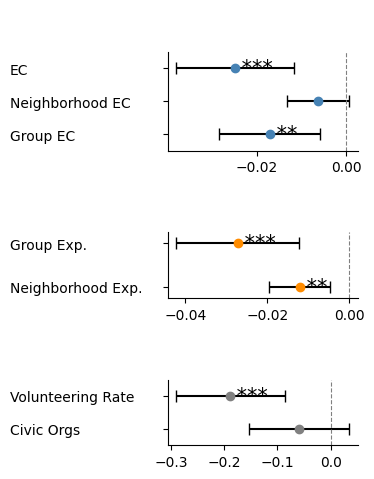

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
slm_plot = results.copy()

slm_plot["x_variable"] = slm_plot["Variable"]
slm_plot["Coefficient"] = slm_plot["SLM_coef"]
slm_plot["CI_Lower"] = slm_plot["SLM_coef"] - 1.96 * slm_plot["SLM_se"]
slm_plot["CI_Upper"] = slm_plot["SLM_coef"] + 1.96 * slm_plot["SLM_se"]
slm_plot["p_value"] = slm_plot["SLM_p"]

coef_df_plot = slm_plot[
    slm_plot["x_variable"].isin(x_vars_plot)
].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

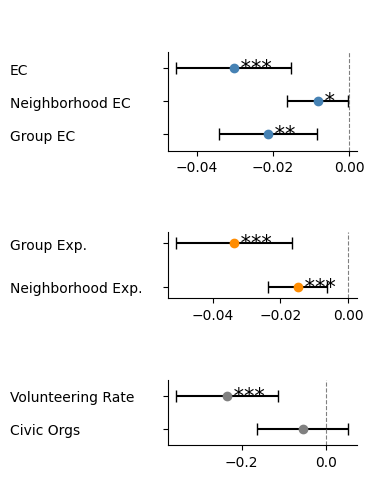

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
sem_plot = results.copy()

sem_plot["x_variable"] = sem_plot["Variable"]
sem_plot["Coefficient"] = sem_plot["SEM_coef"]
sem_plot["CI_Lower"] = sem_plot["SEM_coef"] - 1.96 * sem_plot["SEM_se"]
sem_plot["CI_Upper"] = sem_plot["SEM_coef"] + 1.96 * sem_plot["SEM_se"]
sem_plot["p_value"] = sem_plot["SEM_p"]

coef_df_plot = sem_plot[
    sem_plot["x_variable"].isin(x_vars_plot)
].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [28]:
import pandas as pd
import math
import re

# ==========================================================
# Order of variables
# ==========================================================

display_order = [
    k for k in reversed(list(x_label_mapping.keys()))
    if k != "const"
]
results_table = results.copy()

results_table["Variable"] = pd.Categorical(
    results_table["Variable"],
    categories=display_order,
    ordered=True
)

results_table = results_table.sort_values("Variable").reset_index(drop=True)

# ==========================================================
# significance stars
# ==========================================================

def stars(p):

    if p < 0.001:
        return r"$^{\tiny ***}$"
    elif p < 0.01:
        return r"$^{\tiny **}$"
    elif p < 0.05:
        return r"$^{\tiny *}$"
    else:
        return ""

# ==========================================================
# Build one LaTeX table
# ==========================================================

def build_spatial_table(df, model="SLM", start_idx=1):

    variables = list(df["Variable"])

    columns = []

    for i, (_, r) in enumerate(df.iterrows()):

        col = {}

        # -----------------------------
        # coefficient rows
        # -----------------------------

        for v in display_order:

            label = x_label_mapping[v]

            if v == r["Variable"]:

                if model == "SLM":

                    coef = r["SLM_coef"]
                    se = r["SLM_se"]
                    p = r["SLM_p"]

                else:

                    coef = r["SEM_coef"]
                    se = r["SEM_se"]
                    p = r["SEM_p"]

                col[label] = (
                    f"{coef:.3f}{stars(p)}",
                    f"({se:.3f})"
                )

            else:

                col[label] = ("", "")

        # -----------------------------
        # Model statistics
        # -----------------------------

        col["Damage index"] = ("Yes","")
        col["Demographics"] = ("Yes","")
        col["Disaster FE"] = ("Yes","")

        col["N"] = (f'{int(r["N"]):,}',"")

        if model=="SLM":

            col[r"$\rho$"] = (
                f'{r["rho"]:.3f}{stars(r["rho_p"])}',
                ""
            )

            col["Log likelihood"] = (
                f'{r["SLM_LL"]:.1f}',
                ""
            )

            col["AIC"] = (
                f'{r["SLM_AIC"]:.1f}',
                ""
            )

        else:

            col[r"$\lambda$"] = (
                f'{r["lambda"]:.3f}{stars(r["lambda_p"])}',
                ""
            )

            col["Log likelihood"] = (
                f'{r["SEM_LL"]:.1f}',
                ""
            )

            col["AIC"] = (
                f'{r["SEM_AIC"]:.1f}',
                ""
            )

        columns.append(col)

    # ----------------------------------------------------
    # Build dataframe
    # ----------------------------------------------------

    row_labels = [
        x_label_mapping[v]
        for v in display_order
    ]

    if model=="SLM":
        row_labels.append(r"$\rho$")
    else:
        row_labels.append(r"$\lambda$")

    row_labels += [
        "Damage index",
        "Demographics",
        "Disaster FE",
        "N",
        "Log likelihood",
        "AIC"
    ]

    rows=[]

    for label in row_labels:

        coef_row=[label]
        se_row=[""]

        for c in columns:

            coef,se=c[label]

            coef_row.append(coef)
            se_row.append(se)

        rows.append(coef_row)

        if any(x!="" for x in se_row[1:]):
            rows.append(se_row)

    table=pd.DataFrame(

        rows,

        columns=[""]+[
            f"({i})"
            for i in range(
                start_idx,
                start_idx+len(columns)
            )
        ]

    )

    latex=table.to_latex(

        index=False,

        escape=False,

        column_format="l"+"c"*len(columns)

    )

    latex=latex.replace(

        r"\begin{table}",

        r"\begin{table}\footnotesize"

    )

    return latex

# ==========================================================
# Split into two tables
# ==========================================================

mid = math.ceil(len(results_table)/2)

left = results_table.iloc[:mid]

right = results_table.iloc[mid:]

# ==========================================================
# SLM
# ==========================================================

latex_slm_left = build_spatial_table(
    left,
    model="SLM",
    start_idx=1
)

latex_slm_right = build_spatial_table(
    right,
    model="SLM",
    start_idx=mid+1
)

# ==========================================================
# SEM
# ==========================================================

latex_sem_left = build_spatial_table(
    left,
    model="SEM",
    start_idx=1
)

latex_sem_right = build_spatial_table(
    right,
    model="SEM",
    start_idx=mid+1
)

print(latex_slm_left)
print(latex_slm_right)

print(latex_sem_left)
print(latex_sem_right)

\begin{tabular}{lcccccccc}
\toprule
 & (1) & (2) & (3) & (4) & (5) & (6) & (7) & (8) \\
\midrule
EC & -0.025$^{\tiny ***}$ &  &  &  &  &  &  &  \\
 & (0.007) &  &  &  &  &  &  &  \\
Group EC &  & -0.017$^{\tiny **}$ &  &  &  &  &  &  \\
 &  & (0.006) &  &  &  &  &  &  \\
Neighborhood EC &  &  & -0.006 &  &  &  &  &  \\
 &  &  & (0.004) &  &  &  &  &  \\
EC (high) &  &  &  & -0.027$^{\tiny ***}$ &  &  &  &  \\
 &  &  &  & (0.006) &  &  &  &  \\
Neighborhood EC (high) &  &  &  &  & -0.009$^{\tiny *}$ &  &  &  \\
 &  &  &  &  & (0.003) &  &  &  \\
Group EC (high) &  &  &  &  &  & -0.023$^{\tiny ***}$ &  &  \\
 &  &  &  &  &  & (0.006) &  &  \\
Group Exp. &  &  &  &  &  &  & -0.027$^{\tiny ***}$ &  \\
 &  &  &  &  &  &  & (0.008) &  \\
Group Exp. (high) &  &  &  &  &  &  &  & -0.029$^{\tiny ***}$ \\
 &  &  &  &  &  &  &  & (0.007) \\
Neighborhood Exp. &  &  &  &  &  &  &  &  \\
Group Bias &  &  &  &  &  &  &  &  \\
Group Bias (high) &  &  &  &  &  &  &  &  \\
Neighborhood Bias &  &  &  &  

In [23]:
pip install stargazer

# Shapley R^2

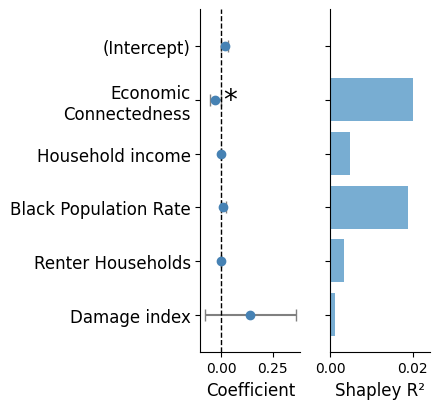

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from collections import defaultdict

# -----------------------------
# 1. Stars
# -----------------------------
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# -----------------------------
# 2. Labels（この変数だけ表示）
# -----------------------------
var_labels = {
    "const": "(Intercept)",
    "ec_zip": "Economic\nConnectedness",
    "Black_Population_Ratio": "Black Population Rate",
    "Renter_Households": "Renter Households",
    "D_TH": "Damage index",
    "Median_Household_Income": "Household income",
}

vars_to_keep = list(var_labels.keys())

# -----------------------------
# 3. Model
# -----------------------------
model = regression_results_ivw["ec_zip"]

coefs = model.params.copy()
conf_int = model.conf_int()
pvals = model.pvalues

# var_labels vars only
coefs = coefs.loc[coefs.index.intersection(vars_to_keep)]
conf_int = conf_int.loc[coefs.index]
pvals = pvals.loc[coefs.index]

coef_names = [var_labels[v] for v in coefs.index]
coef_values = coefs.values
lower = coef_values - conf_int[0].values
upper = conf_int[1].values - coef_values
signif_labels = [significance_stars(p) for p in pvals]

# -----------------------------
# 4. Shapley R²
# -----------------------------
X_full = model.model.exog
y = model.model.endog
exog_names = model.model.exog_names

keep_idx = [
    i for i, v in enumerate(exog_names)
    if (v in vars_to_keep)
]

X = X_full[:, keep_idx]
vars_kept = [exog_names[i] for i in keep_idx]

shapley_r2 = defaultdict(float)
n_samples = 1000
np.random.seed(0)

for _ in range(n_samples):
    perm = np.random.permutation(len(vars_kept))
    current_X = np.ones((len(y), 1))
    r2_prev = 0

    for idx in perm:
        current_X = np.column_stack([current_X, X[:, idx]])
        r2_curr = sm.OLS(y, current_X).fit().rsquared
        shapley_r2[vars_kept[idx]] += r2_curr - r2_prev
        r2_prev = r2_curr

for k in shapley_r2:
    shapley_r2[k] /= n_samples

shapley_r2_list = [
    0 if v == "const" else shapley_r2.get(v, 0)
    for v in coefs.index
]

# -----------------------------
# 5. Plot
# -----------------------------
fig, (ax_coef, ax_r2) = plt.subplots(
    ncols=2, sharey=True,
    figsize=(4.5, len(coef_names) * 0.7)
)

y_pos = np.arange(len(coef_names))

# Coefficients
ax_coef.errorbar(
    coef_values, y_pos,
    xerr=[lower, upper],
    fmt='o', color='steelblue',
    ecolor='gray', capsize=4
)
ax_coef.axvline(0, color='black', linestyle='--', linewidth=1)

for i, s in enumerate(signif_labels):
    if s:
        offset = 0.04
        ax_coef.text(
            coef_values[i] + offset,
            i,
            s,
            va='center',
            fontsize=20
        )

ax_coef.set_xlabel("Coefficient", fontsize=12)
ax_coef.set_yticks(y_pos)
ax_coef.set_yticklabels(coef_names, fontsize=12)
ax_coef.invert_yaxis()
ax_coef.spines['top'].set_visible(False)
ax_coef.spines['right'].set_visible(False)

# Shapley R²
ax_r2.barh(y_pos, shapley_r2_list, alpha=0.6)
ax_r2.set_xlabel("Shapley R²", fontsize=12)
ax_r2.set_xlim(
    0,
    max(shapley_r2_list) * 1.2 if max(shapley_r2_list) > 0 else 0.01
)
ax_r2.spines['top'].set_visible(False)
ax_r2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()

from google.colab import files
files.download("figure.png")


#TEX

In [94]:
from statsmodels.iolib.summary2 import summary_col
import re
import math

# ==================================================
# 0. Significance stars
# ==================================================
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# ==================================================
# 1. Variable groups
# ==================================================
demographics_vars = {
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
}

damage_index_vars = {
    "D_TH",
}

disaster_fe_prefix = "disaster"

# ==================================================
# 2. Variable labels
# ==================================================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Bias (high)",
    "nbhd_bias_zip": "Neighborhood Bias",
    "bias_grp_mem_high_zip": "Group Bias (high)",
    "bias_grp_mem_zip": "Group Bias",
    "nbhd_exposure_zip": "Neighborhood Exp.",
    "exposure_grp_mem_high_zip": "Group Exp. (high)",
    "exposure_grp_mem_zip": "Group Exp.",
    "ec_grp_mem_high_zip": "Group EC (high)",
    "nbhd_ec_high_zip": "Neighborhood EC (high)",
    "ec_high_zip": "EC (high)",
    "nbhd_ec_zip": "Neighborhood EC",
    "ec_grp_mem_zip": "Group EC",
    "ec_zip": "EC",
    "const": "const",
}

target_vars = list(x_label_mapping.keys())

# ==================================================
# 3. Helper functions
# ==================================================
def has_any(model, vars_set):
    return any(v in model.model.exog_names for v in vars_set)

def has_prefix(model, prefix):
    return any(v.startswith(prefix) for v in model.model.exog_names)

# ==================================================
# 4. Build LaTeX table
# ==================================================
def format_latex_table(models, start_idx):

    table = summary_col(
        models,
        stars=False,   # Add significance stars manually
        model_names=[f"({i})" for i in range(start_idx, start_idx + len(models))],
        info_dict={
            "Damage index": lambda x: "Yes" if has_any(x, damage_index_vars) else "No",
            "Demographics": lambda x: "Yes" if has_any(x, demographics_vars) else "No",
            "Disaster FE": lambda x: "Yes" if has_prefix(x, disaster_fe_prefix) else "No",
            "N": lambda x: f"{int(x.nobs)}",
            "R-squared": lambda x: f"{x.rsquared:.3f}",
        },
    )

    df = table.tables[0]

    # -------------------------------------------------
    # Add significance stars to coefficient estimates
    # -------------------------------------------------
    model_cols = df.columns

    for col, model in zip(model_cols, models):

        params = model.params
        pvals = model.pvalues

        for var in params.index:

            if var not in df.index:
                continue

            coef = params[var]
            star = significance_stars(pvals[var])

            df.loc[var, col] = f"{coef:.3f}{star}"

    # -------------------------------------------------
    # Keep only selected variables, standard errors,
    # and summary statistics
    # -------------------------------------------------
    keep_pos = set()
    n = len(df)

    summary_rows = {
        "R-squared",
        "R-squared Adj.",
        "N",
        "Damage index",
        "Demographics",
        "Disaster FE",
    }

    for i in range(n):

        idx = df.index[i]
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in target_vars:
            keep_pos.add(i)
            if i + 1 < n:
                keep_pos.add(i + 1)

        elif base in summary_rows:
            keep_pos.add(i)

    df = df.iloc[sorted(keep_pos)]

    # -------------------------------------------------
    # Replace variable names with display labels
    # -------------------------------------------------
    new_index = []
    last_label = ""

    for idx in df.index:

        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in x_label_mapping:
            label = x_label_mapping[base]
            last_label = label

        else:
            if "(" in idx:
                label = f"{last_label} {idx}"
            else:
                label = base

        new_index.append(label)

    df.index = new_index

    table.tables[0] = df

    latex = table.as_latex()

    # Use a smaller font size
    latex = latex.replace(
        r"\begin{table}",
        r"\begin{table}\footnotesize"
    )

    # Format all numeric values to three decimal places
    latex = re.sub(
        r"(-?\d+\.\d+)",
        lambda m: f"{float(m.group()):.3f}",
        latex,
    )

    # Convert significance stars to tiny superscripts
    latex = re.sub(
        r"(\*{1,3})",
        r"$^{\\tiny \1}$",
        latex,
    )

    return latex

# ==================================================
# 5. Split models into two tables
# ==================================================
models = [v["model"] for v in reversed(latex_results.values())]

mid = math.ceil(len(models) / 2)

models_left = models[:mid]
models_right = models[mid:]

latex_left = format_latex_table(models_left, 1)
latex_right = format_latex_table(models_right, mid + 1)

print(latex_left)
print(latex_right)

\begin{table}\footnotesize
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                       & (1)       & (2)       & (3)       & (4)      & (5)       & (6)      & (7)       & (8)       \\
\hline
const                  & -0.001$^{\tiny ***}$ & -0.001$^{\tiny ***}$ & -0.001$^{\tiny ***}$ & -0.000$^{\tiny *}$  & -0.001$^{\tiny ***}$ & -0.000   & -0.001$^{\tiny ***}$ & -0.000$^{\tiny *}$   \\
                       & (0.000)  & (0.000)  & (0.000)  & (0.000) & (0.000)  & (0.000) & (0.000)  & (0.000)  \\
EC                     & 0.000     &           &           &          &           &          &           &           \\
                       & (0.000)  &           &           &          &           &          &           &           \\
Neighborhood EC        &           & 0.000     &           &          &           &          &           &           \\
                       &           & (0.000)  &           &          &           &          &           &    